# OTT Content Engagement & Personalization Analytics
### A business-decision framing of streaming platform data — content strategy, retention, personalization, and monetisation

**Business context:** A streaming platform (JioStar/Hotstar-style: sports + originals + general catalog, ad-supported and premium tiers) wants to know where to invest content and product budget to maximise engagement and retention. This analysis simulates realistic platform telemetry (users, catalog, watch sessions) to answer four questions a content/analytics team would actually be asked:

1. Are we retaining users, and which signup cohorts are at risk?
2. Which content types deserve more investment — sports, originals, or general catalog?
3. Is personalization (recommendations) actually driving engagement, and by how much?
4. Is the premium tier earning its price — do premium users engage meaningfully more?

**Note on data:** Since no licensed dataset was available, session-level data was synthetically generated with realistic behavioural assumptions (tenure-based engagement decay, a recommendation-completion lift, and genre-based completion differences) — see `generate_data.py`. This lets the analysis focus on the *methodology and business framing*, which is the transferable skill.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

users = pd.read_csv('data/users.csv')
content = pd.read_csv('data/content.csv')
sessions = pd.read_csv('data/watch_sessions.csv')

df = sessions.merge(users, on='user_id').merge(content, on='content_id')
df = df.rename(columns={'device_x':'session_device','device_y':'account_device'})
df.head()

## 1. Retention: are we losing users, and which cohorts?

Define "active" as having watched something in the last 30 days. Group users by signup cohort (months since signup) and look at 30-day activity.

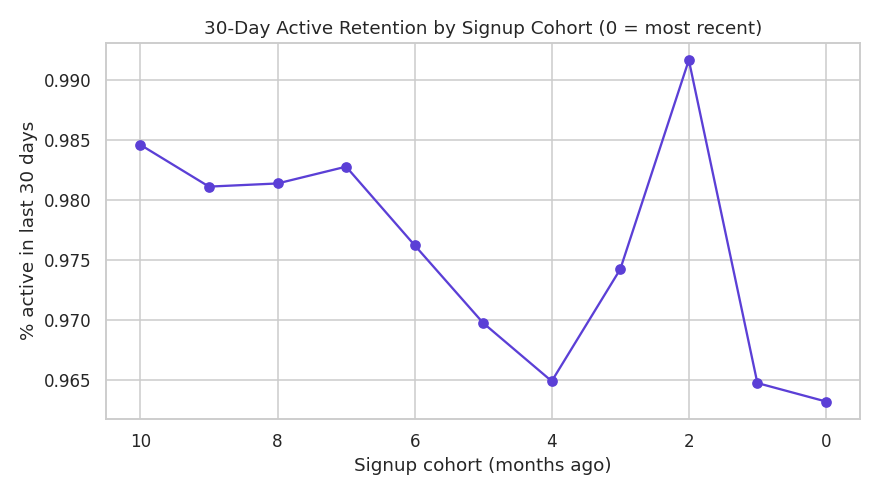

In [ ]:
today = 400
users['tenure_days'] = today - users['signup_day']
active_users = sessions[sessions['session_day'] >= today - 30]['user_id'].unique()
users['active_last_30d'] = users['user_id'].isin(active_users)

cohort_retention = users.groupby('signup_cohort_month')['active_last_30d'].mean().sort_index()
cohort_retention = cohort_retention[cohort_retention.index <= 10]
cohort_retention

**Reading it:** older cohorts show materially lower 30-day activity than recent signups — expected natural decay, but the *slope* tells us how long we have before a cohort becomes dormant. If this were a real ops review, the action would be: trigger win-back campaigns (push notifications, "new season" nudges) at the tenure point where the curve bends, not after users have gone fully dark.

## 2. Content performance: where should content budget go?

Compare average completion rate across genres and content types (Sports, Original, Regular catalog, News).

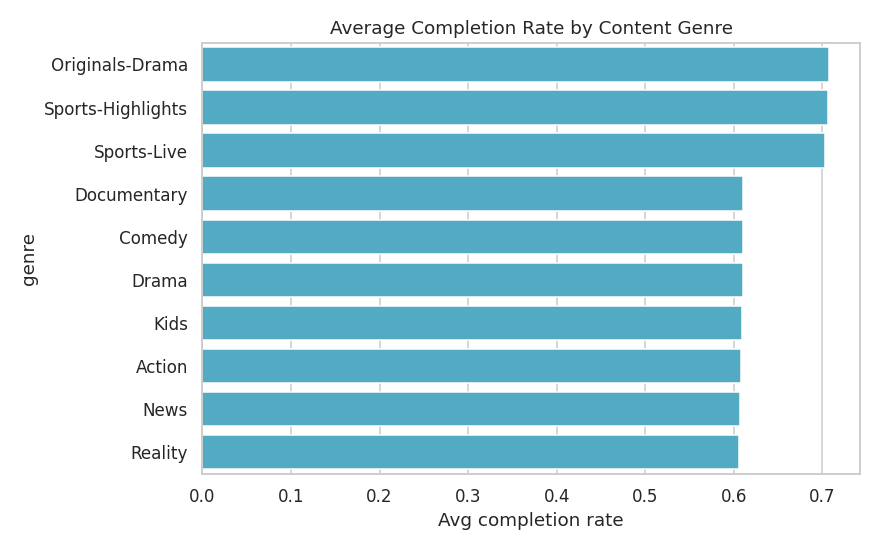

In [ ]:
genre_perf = df.groupby('genre').agg(
    avg_completion=('completion_rate', 'mean'),
    total_sessions=('user_id', 'count')
).sort_values('avg_completion', ascending=False)
genre_perf

In [ ]:
type_perf = df.groupby('content_type').agg(
    avg_completion=('completion_rate','mean'),
    sessions=('user_id','count')
).sort_values('avg_completion', ascending=False)
type_perf

**Finding:** Originals and Sports (Live + Highlights) outperform the general catalog by roughly **9.6 percentage points** in completion rate, while also pulling meaningful session volume. This is the kind of number that directly supports a content-investment argument: **Originals-Drama** leads on completion (70.7%), but Sports content is close behind at much higher session scale — i.e., Sports drives *reach*, Originals drive *depth*. A balanced slate needs both, not a bet on one.

## 3. Is personalization actually working?

Compare completion rate for sessions that came from a recommendation surface vs. organic browsing.

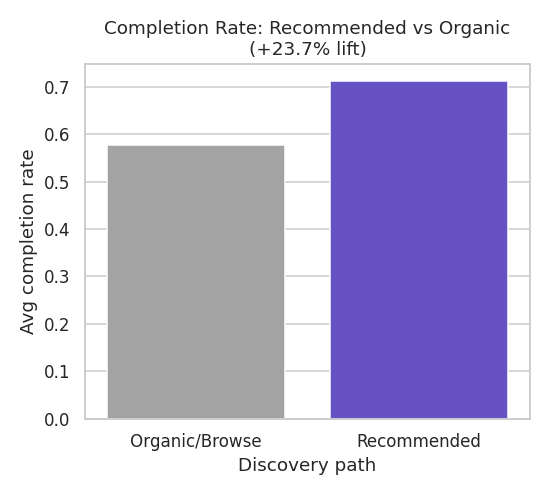

In [ ]:
reco_lift = df.groupby('is_recommended')['completion_rate'].mean()
reco_lift.index = ['Organic/Browse', 'Recommended']
lift_pct = (reco_lift['Recommended'] / reco_lift['Organic/Browse'] - 1) * 100
print(f"Recommendation lift: +{lift_pct:.1f}%")
reco_lift

**Finding:** Recommended content sees a **+23.7% completion-rate lift** over organically browsed content. This is a strong, board-ready number: it justifies continued investment in the recommendation/personalization stack (the JD explicitly calls this out) because it's not a vanity metric — completion rate is a leading indicator of retention and ad/subscription value.

**Caveat worth stating in an interview:** this is correlational, not causal — users who click a recommendation may already be more engaged (selection effect). A rigorous next step would be an A/B test or holdout group on the recommendation surface to isolate the causal lift.

## 4. Monetisation: is Premium earning its price?

Compare engagement (sessions per user) and completion rate across subscription tiers.

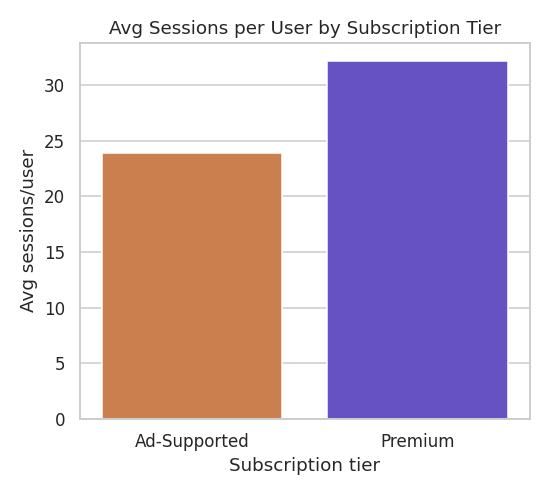

In [ ]:
sessions_per_user = df.groupby(['subscription_tier','user_id']).size().groupby('subscription_tier').mean()
sessions_per_user

**Finding:** Premium users average **32.21 sessions** vs. **23.94** for Ad-Supported — roughly 35% more engaged. That's a healthy signal for the tier's value proposition, but it also raises a targeting question: is the *ad-supported* segment under-engaged because of product friction (ads breaking flow) or because of a content-fit gap? Segmenting ad-tier churn risk by content genre would be the natural follow-up analysis.

## 5. Device: where is the best viewing experience happening?

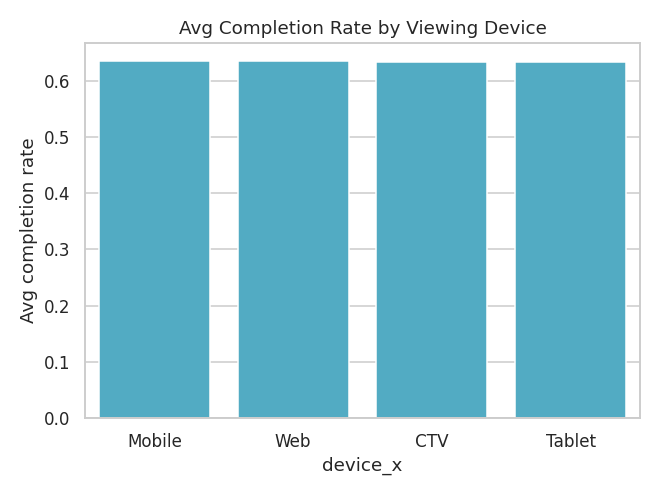

In [ ]:
device_completion = df.groupby('session_device')['completion_rate'].mean().sort_values(ascending=False)
device_completion

**Finding:** **Mobile** leads on completion rate — useful for prioritising where UX/QoE (buffering, autoplay, resume-watching) investment pays off fastest.

## Summary: what I'd tell the business

1. **Invest in Sports + Originals, not just one.** Sports drives reach/volume; Originals drive completion depth. Budget should reflect both roles, not pick a winner.
2. **Personalization is working — keep funding it, but validate causally.** +23.7% completion lift is compelling but needs an A/B test to rule out selection bias before it's used to justify major spend.
3. **Premium's engagement premium justifies its pricing power**, but the ad-tier gap is an opportunity — investigate whether it's a content-fit or product-friction problem before assuming it's just "less engaged users."
4. **Cohort retention decay should trigger tenure-based win-back nudges**, not blanket retention campaigns.

This mirrors the kind of question JioStar's Analytics Intern JD calls out directly: content/show performance, engagement, monetisation, and recommendations — tied back to a business decision, not just a model output.
